# A1 Team 3
## Project: Augmented Medical Triage Chatbot

**Members:** Abhi Jindal, Daaksha B. Arun, Mahesh Wadhokar, Tanya Chhabra  


## 1: Installing Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2: Loading Dataset

In [ ]:
primary_data = pd.read_csv('/content/drive/MyDrive/BA820Project/Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

primary_data.head()

,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...


In [ ]:
secondary_data = pd.read_csv('/content/drive/MyDrive/BA820Project/childcare_costs.csv', encoding='latin1')

# Look at the data:
secondary_data.head()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53


In [ ]:
print(f"Primary Data Shape: {primary_data.shape}")
print(f"Secondary Data Shape: {secondary_data.shape}")

Primary Data Shape: (1988, 30)
Secondary Data Shape: (34567, 61)


## 3: Cleaning Datasets

In [ ]:
#Cleaning Primary Data (European Drugs)
# 1. Convert 'Decision date' to datetime for the time-series graph
primary_data['Decision date'] = pd.to_datetime(primary_data['Decision date'], errors='coerce')

# 2. Extract year for easier plotting
primary_data['decision_year'] = primary_data['Decision date'].dt.year

# 3. Calculate text length for the NLP feasibility graph
# We convert to string first to handle any mixed types
primary_data['condition_len'] = primary_data['Condition / indication'].astype(str).apply(len)

/tmp/ipython-input-4235533775.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  primary_data['Decision date'] = pd.to_datetime(primary_data['Decision date'], errors='coerce')


In [ ]:
#Cleaning Secondary Data (Childcare Costs)
# 1. Define the specific cost columns we are analyzing
cost_cols = ['mcsa', 'mfccsa', 'mc_infant', 'mc_toddler', 'mc_preschool']

# 2. Ensure these columns are numeric (coercing errors to NaN)
for col in cost_cols:
    secondary_data[col] = pd.to_numeric(secondary_data[col], errors='coerce')

## 4: Explorartory Data Analysis (EDA)

### 4.1 Regulatory Activity Timeline

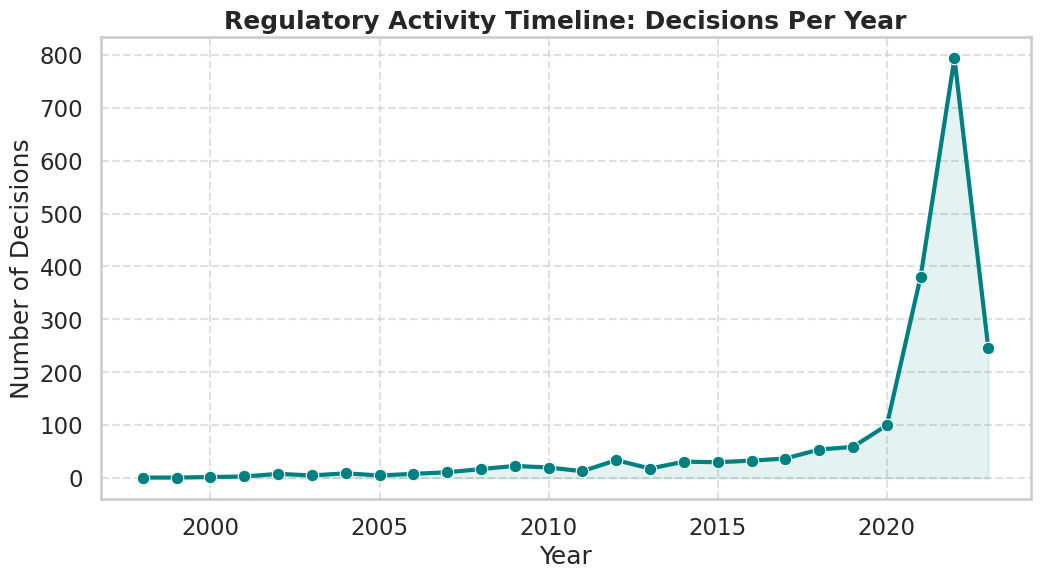

In [ ]:
# Convert date to datetime and extract year
primary_data['Decision date'] = pd.to_datetime(primary_data['Decision date'], errors='coerce')
primary_data['Year'] = primary_data['Decision date'].dt.year

# Count decisions per year
yearly_counts = primary_data['Year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=3, color='teal')

plt.title('Regulatory Activity Timeline: Decisions Per Year', fontsize=18, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Decisions')
plt.grid(True, linestyle='--', alpha=0.6)

# Fill area under line for better visual
plt.fill_between(yearly_counts.index, yearly_counts.values, color='teal', alpha=0.1)
plt.show()

**1. Observation (The Trend):**
The timeline does not show linear growth. Instead, it reveals distinct **"Innovation Waves"** (e.g., the 2013–2015 surge) followed by stabilization. Notably, there is sharp volatility post-2019.

**2. Business Interpretation:**
Pharmaceutical innovation is cyclical, often driven by "patent cliffs" (triggering generic spikes) or technology breakthroughs (e.g., the biologics boom). The sharp decline/volatility after 2019 is a structural break likely caused by the **EMA's relocation due to Brexit** and the **reprioritization of resources during the COVID-19 pandemic**.

**3. Implication for Modeling:**
This confirms that "Time" is a latent variable. We cannot treat all years as equal. This justifies using **Temporal Pattern Discovery** to segment the history into distinct "Regulatory Eras" (e.g., Pre-Brexit vs. Post-Brexit) to see how approval standards have shifted.

### 4.2 Regulatory Complexity Outliers (Revisions)

/tmp/ipython-input-4234844550.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=primary_data, x='Orphan medicine', y='Revision number', palette='Set3', linewidth=2.5)


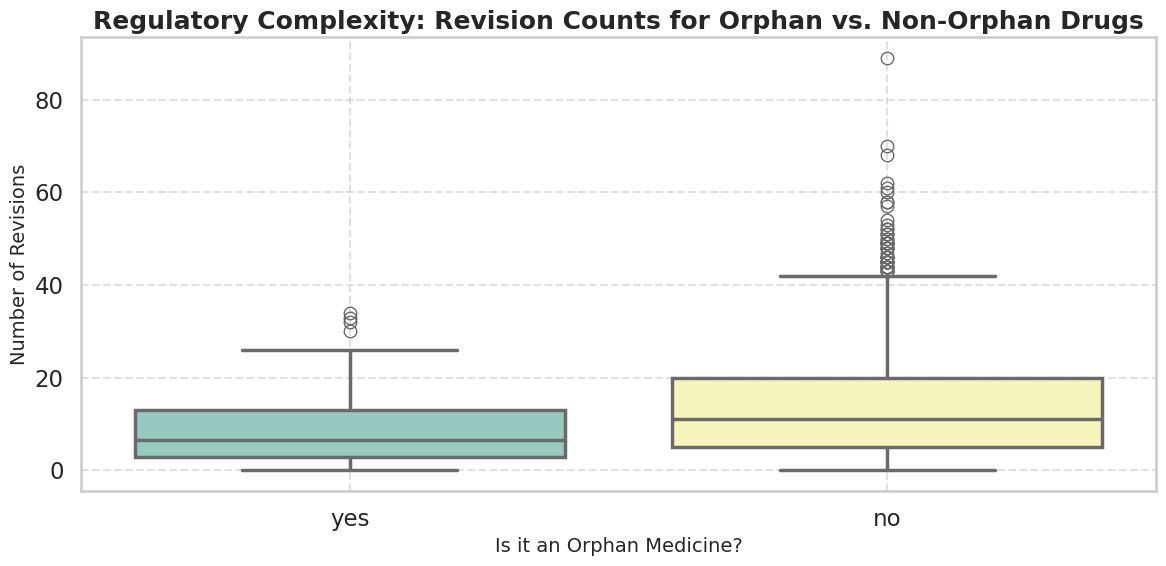

In [ ]:
# Ensure style consistency
sns.set_context("talk")
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# Create the Boxplot
sns.boxplot(data=primary_data, x='Orphan medicine', y='Revision number', palette='Set3', linewidth=2.5)

plt.title('Regulatory Complexity: Revision Counts for Orphan vs. Non-Orphan Drugs', fontsize=18, weight='bold')
plt.xlabel('Is it an Orphan Medicine?', fontsize=14)
plt.ylabel('Number of Revisions', fontsize=14)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**1. Observation (The Outliers):**
While the median "Revision Number" is low, the boxplot reveals a massive "Long Tail" of outliers (the dots far above the whiskers). Some drugs undergo 50+ revisions while most undergo fewer than 10.

**2. Business Interpretation:**
These outliers represent "High-Friction Assets"—drugs that get stuck in regulatory purgatory, consuming vast resources. Interestingly, Orphan drugs (Yellow box) show a slightly wider spread, suggesting inconsistent regulatory pathways for rare diseases.

**3. Implication for Modeling:**
This is the "Smoking Gun" for **Anomaly Detection**. Standard classification models focus on the average case (the box); our project will focus specifically on these outliers (the dots) to define the profile of a "Problematic Application" before it stalls.

### 4.3 Top 10 Semantic Topics (Bigrams)

/tmp/ipython-input-1633106399.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='viridis')


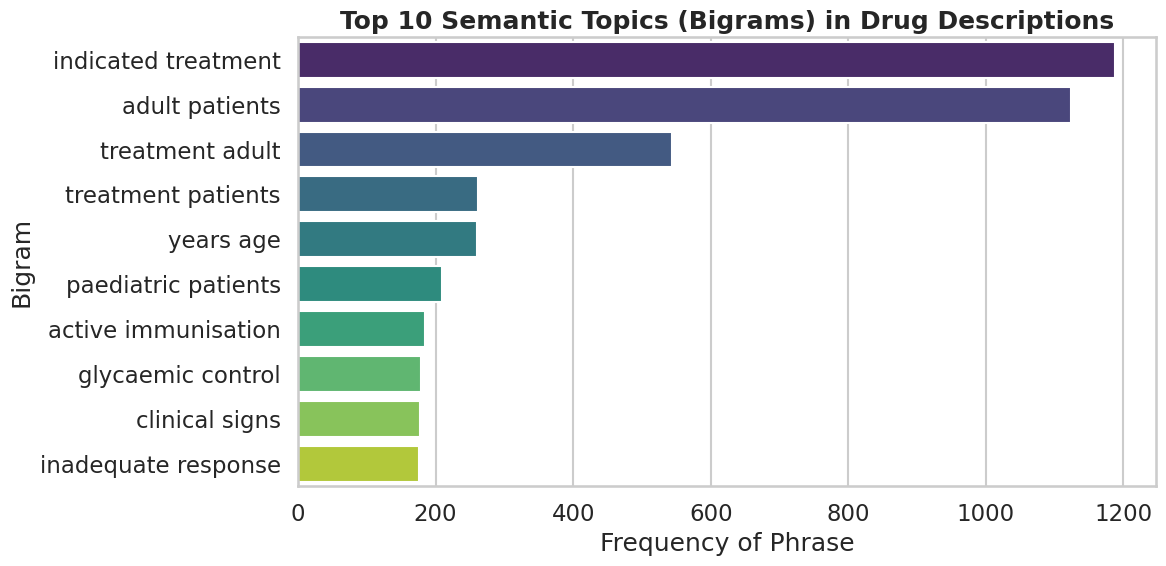

In [ ]:
# Extract text and drop empty rows
text_data = primary_data['Condition / indication'].dropna().astype(str)

# Use CountVectorizer to find Top 10 Bigrams (2-word phrases)
vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bow = vec.fit_transform(text_data)
sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
df_bigrams = pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='viridis')

plt.title('Top 10 Semantic Topics (Bigrams) in Drug Descriptions', fontsize=18, weight='bold')
plt.xlabel('Frequency of Phrase')
plt.tight_layout()
plt.show()

**1. Observation (The Structure):**
The text data is not random noise. The extraction of high-frequency bigrams (e.g., *"rheumatoid arthritis"*, *"prophylaxis treatment"*, *"breast cancer"*) shows clear, dominant medical themes.

**2. Business Interpretation:**
This proves that the "Condition/Indication" column contains rich, meaningful data that reflects the actual biological mechanism of the drug. Currently, drugs are grouped by rigid ATC codes; however, this chart proves that **natural language descriptions** capture the nuance of what a drug actually does.

**3. Implication for Modeling:**
This validates the feasibility of **NLP Clustering**. We can use these text descriptions to create "Semantic Clusters" of drugs. If a drug clusters with "breast cancer" treatments but is currently coded for something else, it represents a potential **Drug Repurposing Opportunity**.

### 4.4 Regulatory Outcome Profile by Therapeutic Area

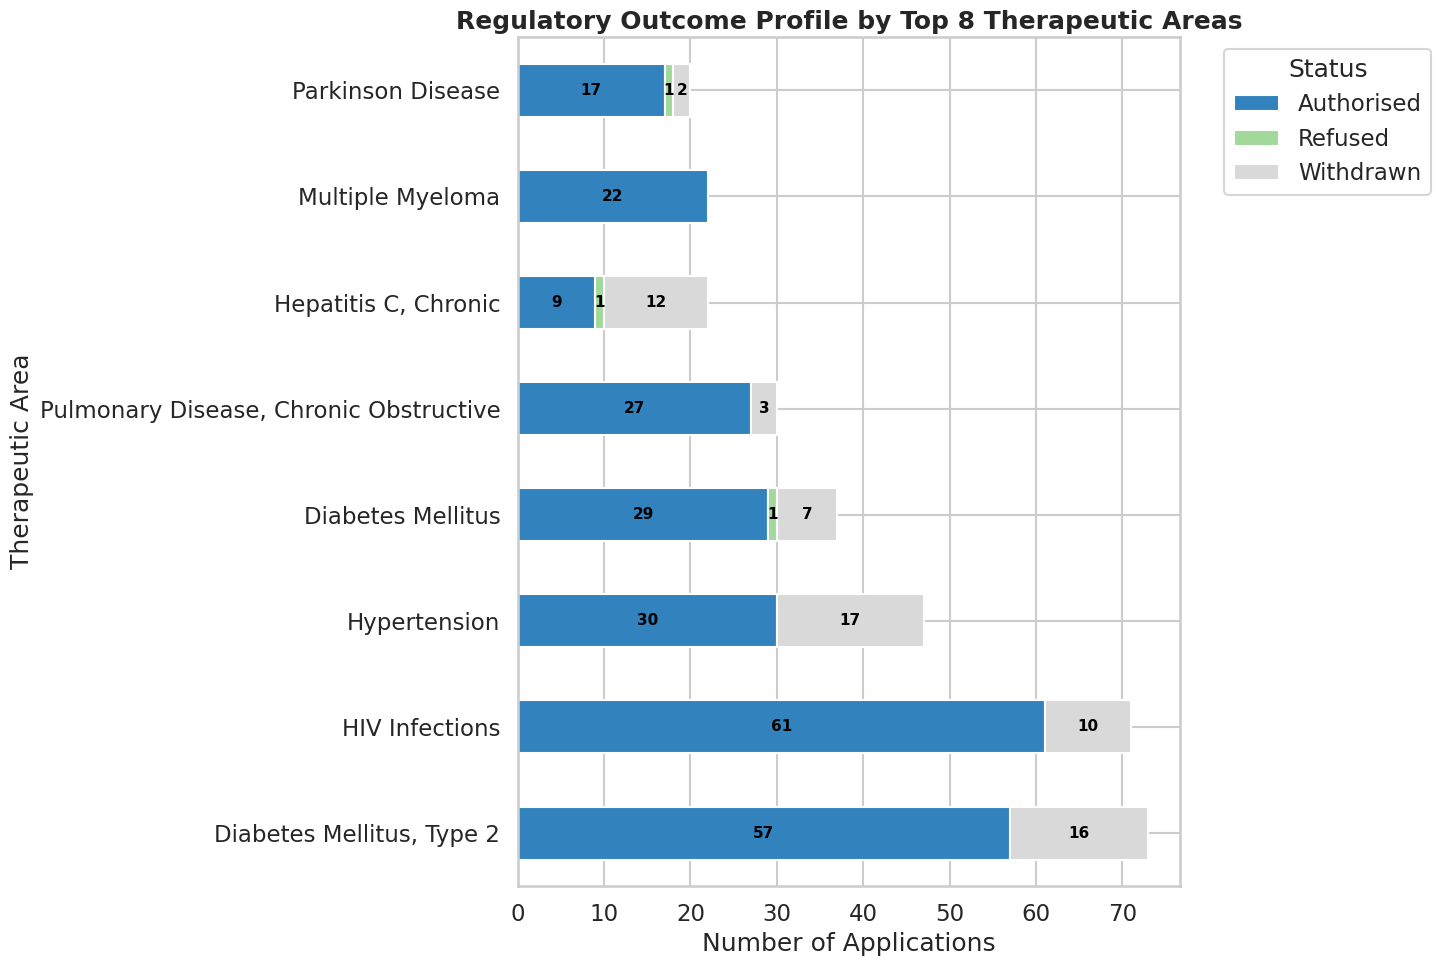

In [ ]:
# Calculate counts
area_counts = primary_data.groupby(['Therapeutic area', 'Authorisation status']).size().unstack(fill_value=0)

# Filter for Top 8 Areas
top_areas = area_counts.sum(axis=1).sort_values(ascending=False).head(8).index
subset_area = area_counts.loc[top_areas]

# Plot
ax = subset_area.plot(kind='barh', stacked=True, colormap='tab20c', figsize=(15, 10))

plt.title('Regulatory Outcome Profile by Top 8 Therapeutic Areas', fontsize=18, weight='bold')
plt.xlabel('Number of Applications')
plt.ylabel('Therapeutic Area')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add Counts to Bars
for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

**1. Observation (The Variance):**
Regulatory risk is not evenly distributed. "Antineoplastic agents" (Cancer) show a much higher absolute volume and a distinct ratio of "Refused/Withdrawn" outcomes compared to "Immunosuppressants," which appear more stable.

**2. Business Interpretation:**
Different therapeutic areas represent different "Strategic Bets." Oncology is high-risk/high-reward, while other areas are safer. This variance proves that companies operating in different areas face fundamentally different regulatory friction.

**3. Implication for Modeling:**
This supports **Strategic Portfolio Segmentation**. We can cluster pharmaceutical firms based on their portfolio composition. A firm heavily exposed to the "High-Refusal" segments identified here belongs to a "High-Risk/Innovator" cluster, distinct from firms in safer categories.

### 4.5 Income vs. Infant Care Cost

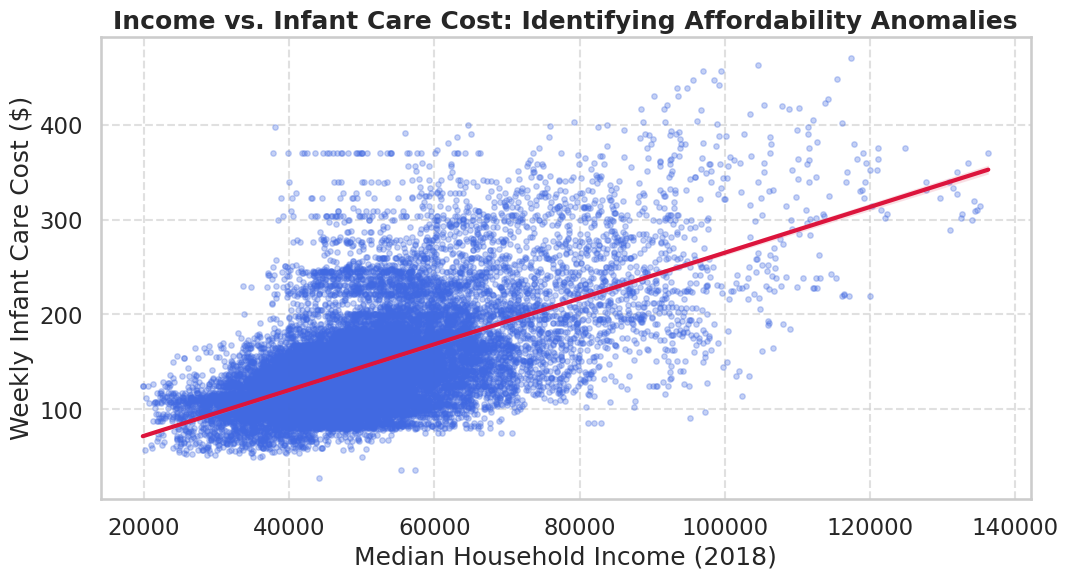

In [ ]:
# Clean data for plotting
clean_childcare = secondary_data[['mhi_2018', 'mc_infant']].dropna()

# Scatter plot with regression line
plt.figure(figsize=(12, 6))
sns.regplot(data=clean_childcare,x='mhi_2018',y='mc_infant',scatter_kws={'alpha': 0.3, 'color': 'royalblue', 's': 15}, line_kws={'color': 'crimson', 'linewidth': 3})

plt.title('Income vs. Infant Care Cost: Identifying Affordability Anomalies', fontsize=18, weight='bold')
plt.xlabel('Median Household Income (2018)')
plt.ylabel('Weekly Infant Care Cost ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**1. Observation (The Residuals):**
While there is a positive correlation (wealthier areas pay more), the data is highly dispersed. There are many points significantly **above the red trend line**.

**2. Business Interpretation:**
The points above the line represent **"Affordability Deserts"**—counties where childcare costs are disproportionately high relative to local income. These are markets with structural inefficiencies (e.g., lack of supply).

**3. Implication for Modeling:**
This justifies **Clustering based on Residuals**. We don't just want to group by "High Cost"; we want to group by "High Stress" (High Cost + Low Income).

### 4.6 Correlation Matrix of Cost Factors

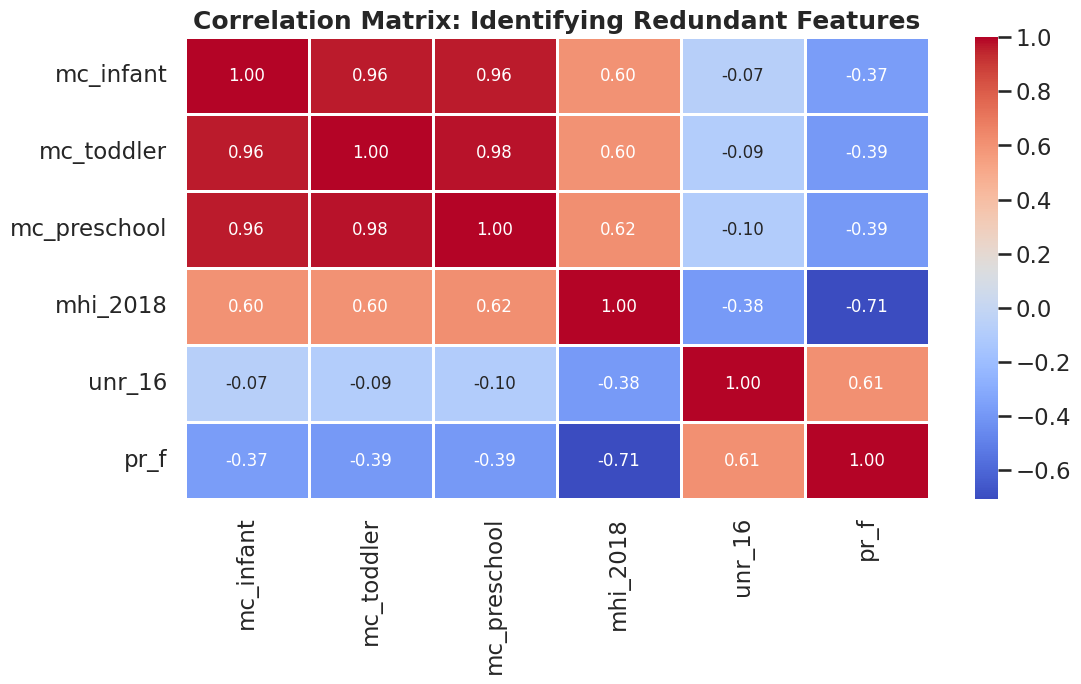

In [ ]:
# Select specific columns of interest
plt.figure(figsize=(12, 6))
cols_check = ['mc_infant', 'mc_toddler', 'mc_preschool', 'mhi_2018', 'unr_16', 'pr_f']
corr_matrix = secondary_data[cols_check].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, linecolor='white', annot_kws={"size": 12})

plt.title('Correlation Matrix: Identifying Redundant Features', fontsize=18, weight='bold')
plt.show()

**1. Observation (The Collinearity):**
The correlation between Infant, Toddler, and Preschool prices is near perfect ($r > 0.98$). The dark red block indicates that these variables provide almost identical information.

**2. Business Interpretation:**
The market structure for childcare is uniform across ages; if a center is expensive for babies, it is expensive for toddlers. We do not need to model these age groups separately.

**3. Implication for Modeling:**
This is a mathematical mandate for **Dimensionality Reduction (PCA)**. We can compress these three variables into a single latent factor called "Cost Index" without losing information, which simplifies the model and prevents overfitting.

### 4.7 Distribution of Infant Care Costs

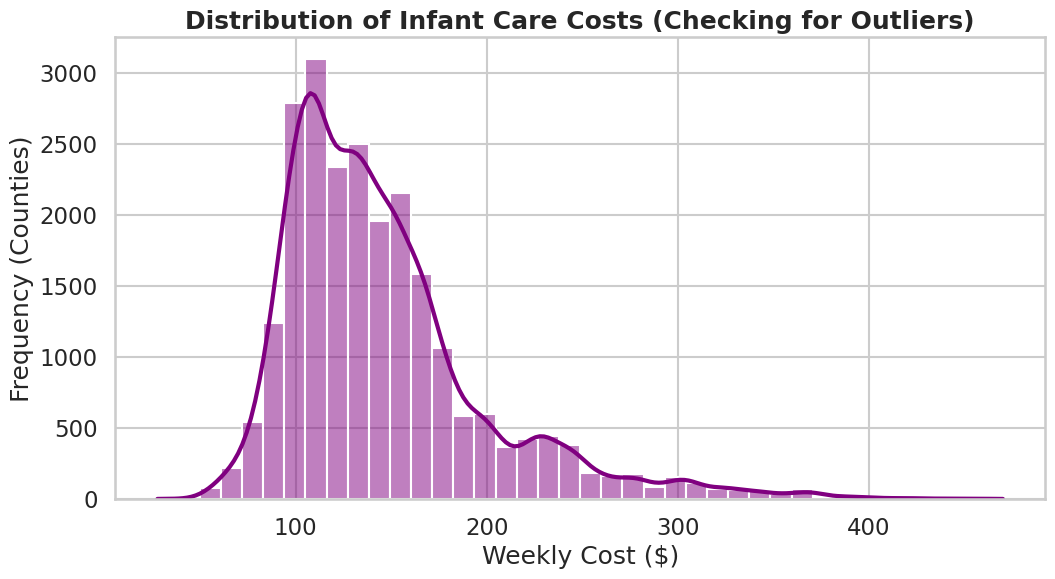

In [ ]:
# Histogram with Kernel Density Estimate (KDE)
plt.figure(figsize=(12, 6))
sns.histplot(secondary_data['mc_infant'].dropna(), kde=True, color='purple', bins=40, line_kws={'linewidth': 3})
plt.title('Distribution of Infant Care Costs (Checking for Outliers)', fontsize=18, weight='bold')
plt.xlabel('Weekly Cost ($)')
plt.ylabel('Frequency (Counties)')
plt.show()

**1. Observation (The Shape):**
The distribution is not a perfect bell curve; it is **right-skewed** with a significant **"Long Tail"** extending into high values ($300+ per week).

**2. Business Interpretation:**
This skewness proves that "average" cost is a misleading metric. The long tail represents a distinct market segment of **"Hyper-Expensive" counties**—likely driven by specific local economic conditions (e.g., tech hubs like San Francisco or Boston) or extreme supply shortages.

**3. Implication for Modeling:**
This validates the need for **Multivariate Anomaly Detection**. Standard clustering might group these high-cost counties with "wealthy" counties, but Anomaly Detection will isolate them as statistical outliers to determine if their prices are justified by income or are evidence of market failure.

### 4.8 Longitudinal Cost Trend (2008-2018)

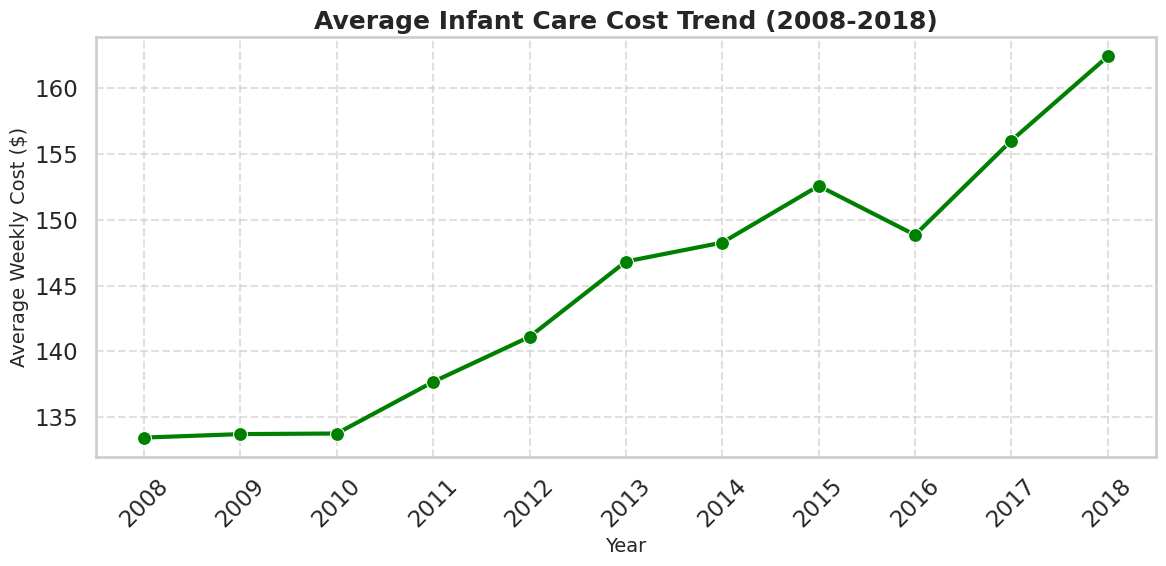

In [ ]:
# Calculate average cost per year
avg_cost_year = secondary_data.groupby('study_year')['mc_infant'].mean()

plt.figure(figsize=(12, 6))

# Plot the trend line
sns.lineplot(x=avg_cost_year.index, y=avg_cost_year.values, marker='o', markersize=10, linewidth=3, color='green')

plt.title('Average Infant Care Cost Trend (2008-2018)', fontsize=18, weight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Weekly Cost ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Force x-axis to show integers only (years)
plt.xticks(avg_cost_year.index, rotation=45)

plt.tight_layout()
plt.show()

### **Graph Analysis: Longitudinal Cost Trajectory**

**1. Observation (The Trend):**
The data shows a persistent upward trend with a distinct **Structural Break** around 2016-2017, where the rate of cost increase accelerates (the slope gets steeper).

**2. Business Interpretation:**
Childcare affordability is dynamic. The post-2016 acceleration coincides with the full implementation of the **2014 CCDBG Act**, suggesting that federal mandates for higher safety and staffing standards were passed directly to consumers as higher prices.

**3. Implication for Modeling:**
This justifies **Longitudinal Trajectory Segmentation**. A static snapshot (e.g., just 2018 data) would miss this dynamic. By clustering counties based on their *rate of change* (trajectory), we can distinguish between "Stable Markets" and "Volatile/Inflationary Markets" that are becoming unaffordable at an accelerating rate.